# Lecture 1: Data and evidence

This notebook examines the PAMA workbook’s scope, reshapes and validates its records, calculates recorded sales shares, and interprets what those results can support.

When the notebook runs in Google Colab, it downloads the prepared CSV files from this public repository if they are not already present.

[Open in Google Colab](https://colab.research.google.com/github/DrFarrukh/teaching/blob/main/courses/data-analysis-and-visualization/lectures/lecture-01/notebook.ipynb). Select **Runtime → Run all**.


In [1]:
# Colab normally provides these packages. Uncomment only if one is missing:
# %pip install pandas matplotlib


## Analytical route

We will investigate four connected questions:

- What records are available, and do they pass basic checks?
- How did annual recorded passenger-car sales change?
- What share of recorded sales belongs to Suzuki, Toyota and Honda?
- How sensitive is that share to an incomplete denominator?

The notebook distinguishes **extraction accuracy** from **market coverage**. A table can pass every computational check while still representing only part of the population named in a claim.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

plt.rcParams.update(
    {
        "figure.figsize": (12, 5.5),
        "font.size": 12,
        "axes.titlesize": 18,
        "axes.labelsize": 13,
        "axes.edgecolor": "#222222",
        "axes.grid": True,
        "grid.color": "#D0D0D0",
        "grid.alpha": 0.7,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)


## 1. Data provenance and loading

The analysis follows this chain:

`PAMA workbook → preparation script → long-format CSV → notebook calculation → figure → conclusion`

In [3]:
from urllib.request import urlretrieve

CURRENT_DIR = Path.cwd()
COURSE_LECTURE = Path("courses/data-analysis-and-visualization/lectures/lecture-01")
candidates = [CURRENT_DIR, *(parent / COURSE_LECTURE for parent in [CURRENT_DIR, *CURRENT_DIR.parents])]
LECTURE_DIR = next((path for path in candidates if (path / "data").is_dir()), None)
if LECTURE_DIR is None:
    LECTURE_DIR = Path("/tmp/teaching-data-analysis-lecture-01")
    (LECTURE_DIR / "data").mkdir(parents=True, exist_ok=True)
DATA_DIR = LECTURE_DIR / "data"

required_files = {
    "long records": DATA_DIR / "passenger_cars_long.csv",
    "annual brand totals": DATA_DIR / "annual_brand_sales.csv",
    "prepared market summary": DATA_DIR / "annual_market_summary.csv",
    "source-total validation": DATA_DIR / "source_total_validation.csv",
}

RAW_DATA_URL = (
    "https://raw.githubusercontent.com/DrFarrukh/teaching/main/"
    "courses/data-analysis-and-visualization/lectures/lecture-01/data"
)
for path in required_files.values():
    if not path.exists():
        urlretrieve(f"{RAW_DATA_URL}/{path.name}", path)

long_data = pd.read_csv(required_files["long records"], parse_dates=["date"])
prepared_brand = pd.read_csv(required_files["annual brand totals"])
prepared_summary = pd.read_csv(required_files["prepared market summary"])
source_validation = pd.read_csv(required_files["source-total validation"])

print(f"Lecture directory: {LECTURE_DIR.resolve()}")
print("All required prepared files are available.")


Lecture directory: .
All required prepared files are available.


In [4]:
file_manifest = pd.DataFrame(
    {
        "artifact": required_files.keys(),
        "file": [path.name for path in required_files.values()],
        "rows": [
            len(long_data),
            len(prepared_brand),
            len(prepared_summary),
            len(source_validation),
        ],
    }
)
display(file_manifest)


,artifact,file,rows
0,long records,passenger_cars_long.csv,4560
1,annual brand totals,annual_brand_sales.csv,87
2,prepared market summary,annual_market_summary.csv,19
3,source-total validation,source_total_validation.csv,380


### Dataset structure

Before calculating a market share, determine what one row represents, which years and categories appear, and whether the proposed key is unique.

The prepared table contains 19 fiscal years, seven manufacturer labels, 22 model groups, and two measures.


In [5]:
display(long_data.head(10))
display(long_data.dtypes.rename("dtype").to_frame())

,fiscal_year,date,manufacturer,model_group,measure,units,source_sheet,source_row
0,2007-08,2007-07-01,Honda,Honda Civic,Production,554,2007-08,9
1,2007-08,2007-08-01,Honda,Honda Civic,Production,533,2007-08,9
2,2007-08,2007-09-01,Honda,Honda Civic,Production,405,2007-08,9
3,2007-08,2007-10-01,Honda,Honda Civic,Production,662,2007-08,9
4,2007-08,2007-11-01,Honda,Honda Civic,Production,423,2007-08,9
5,2007-08,2007-12-01,Honda,Honda Civic,Production,363,2007-08,9
6,2007-08,2008-01-01,Honda,Honda Civic,Production,477,2007-08,9
7,2007-08,2008-02-01,Honda,Honda Civic,Production,598,2007-08,9
8,2007-08,2008-03-01,Honda,Honda Civic,Production,332,2007-08,9
9,2007-08,2008-04-01,Honda,Honda Civic,Production,419,2007-08,9


,dtype
fiscal_year,str
date,datetime64[us]
manufacturer,str
model_group,str
measure,str
units,int64
source_sheet,str
source_row,int64


In [6]:
coverage = pd.Series(
    {
        "rows": len(long_data),
        "columns": long_data.shape[1],
        "fiscal years": long_data["fiscal_year"].nunique(),
        "first fiscal year": long_data["fiscal_year"].iloc[0],
        "last fiscal year": long_data["fiscal_year"].iloc[-1],
        "manufacturers": long_data["manufacturer"].nunique(),
        "model groups": long_data["model_group"].nunique(),
        "measures": long_data["measure"].nunique(),
    },
    name="value",
)
display(coverage.to_frame())
print("Manufacturers:", ", ".join(sorted(long_data["manufacturer"].unique())))
print("Measures:", ", ".join(sorted(long_data["measure"].unique())))


,value
rows,4560
columns,8
fiscal years,19
first fiscal year,2007-08
last fiscal year,2025-26
manufacturers,7
model groups,22
measures,2


Manufacturers: BAIC, Daihatsu, Honda, Honri, Hyundai, Suzuki, Toyota
Measures: Production, Sales


In [7]:
missing_audit = long_data.isna().sum().rename("missing_values").to_frame()
missing_audit["missing_percent"] = 100 * missing_audit["missing_values"] / len(long_data)
display(missing_audit)


,missing_values,missing_percent
fiscal_year,0,0.000
date,0,0.000
manufacturer,0,0.000
model_group,0,0.000
measure,0,0.000
units,0,0.000
source_sheet,0,0.000
source_row,0,0.000


In [8]:
observation_key = [
    "fiscal_year",
    "date",
    "manufacturer",
    "model_group",
    "measure",
    "source_sheet",
]

duplicate_count = int(long_data.duplicated(observation_key).sum())
print(f"Duplicate records using the proposed key: {duplicate_count}")


Duplicate records using the proposed key: 0


In [9]:
validation_result = pd.Series(
    {
        "source totals checked": len(source_validation),
        "nonzero differences": int(source_validation["difference"].ne(0).sum()),
        "largest absolute difference": source_validation["difference"].abs().max(),
    },
    name="value",
)
display(validation_result.to_frame())


,value
source totals checked,380.000
nonzero differences,0.000
largest absolute difference,0.000


### Audit interpretation

The prepared table has no missing values or duplicate proposed keys, and all 380 extracted monthly totals match the cached workbook totals.

That result supports the **accuracy of the extraction**. It does not prove that the workbook covers every passenger car sold in Pakistan.


In [10]:
sales = long_data.loc[long_data["measure"].eq("Sales")].copy()
year_order = list(dict.fromkeys(sales["fiscal_year"]))
sales["fiscal_year"] = pd.Categorical(
    sales["fiscal_year"],
    categories=year_order,
    ordered=True,
)

print(f"Sales records retained: {len(sales):,}")
print("Row definition: one model group, in one fiscal month, for the Sales measure.")


Sales records retained: 2,280
Row definition: one model group, in one fiscal month, for the Sales measure.


In [11]:
display(
    sales[
        [
            "fiscal_year",
            "date",
            "manufacturer",
            "model_group",
            "measure",
            "units",
            "source_sheet",
        ]
    ].head(10)
)


,fiscal_year,date,manufacturer,model_group,measure,units,source_sheet
12,2007-08,2007-07-01,Honda,Honda Civic,Sales,418,2007-08
13,2007-08,2007-08-01,Honda,Honda Civic,Sales,630,2007-08
14,2007-08,2007-09-01,Honda,Honda Civic,Sales,305,2007-08
15,2007-08,2007-10-01,Honda,Honda Civic,Sales,581,2007-08
16,2007-08,2007-11-01,Honda,Honda Civic,Sales,348,2007-08
17,2007-08,2007-12-01,Honda,Honda Civic,Sales,315,2007-08
18,2007-08,2008-01-01,Honda,Honda Civic,Sales,521,2007-08
19,2007-08,2008-02-01,Honda,Honda Civic,Sales,579,2007-08
20,2007-08,2008-03-01,Honda,Honda Civic,Sales,449,2007-08
21,2007-08,2008-04-01,Honda,Honda Civic,Sales,527,2007-08


## 2. Annual recorded passenger-car sales

The first calculation asks a descriptive question:

> How did the total number of passenger-car sales recorded in the workbook change across fiscal years?

The denominator question becomes important when we calculate shares.


In [12]:
annual_total = (
    sales.groupby("fiscal_year", observed=True, sort=False)["units"]
    .sum()
    .rename("total_recorded_sales")
    .reset_index()
)
display(annual_total)


,fiscal_year,total_recorded_sales
0,2007-08,164650
1,2008-09,82844
2,2009-10,123957
3,2010-11,127944
4,2011-12,157325
5,2012-13,118830
6,2013-14,118102
7,2014-15,151134
8,2015-16,181145
9,2016-17,185781


In [13]:
summary_check = annual_total.merge(
    prepared_summary[["fiscal_year", "total_recorded_sales"]],
    on="fiscal_year",
    suffixes=("_recalculated", "_prepared"),
)
summary_check["difference"] = (
    summary_check["total_recorded_sales_recalculated"]
    - summary_check["total_recorded_sales_prepared"]
)

display(summary_check)
assert summary_check["difference"].eq(0).all()
print("Recalculated annual totals match the prepared summary.")


,fiscal_year,total_recorded_sales_recalculated,total_recorded_sales_prepared,difference
0,2007-08,164650,164650,0
1,2008-09,82844,82844,0
2,2009-10,123957,123957,0
3,2010-11,127944,127944,0
4,2011-12,157325,157325,0
5,2012-13,118830,118830,0
6,2013-14,118102,118102,0
7,2014-15,151134,151134,0
8,2015-16,181145,181145,0
9,2016-17,185781,185781,0


Recalculated annual totals match the prepared summary.


In [14]:
annual_change = annual_total.assign(
    year_to_year_change=annual_total["total_recorded_sales"].pct_change()
)
display(annual_change)

largest_increase = annual_change.loc[annual_change["year_to_year_change"].idxmax()]
largest_decrease = annual_change.loc[annual_change["year_to_year_change"].idxmin()]

print(
    f"Largest recorded increase: {largest_increase['fiscal_year']} "
    f"({largest_increase['year_to_year_change']:+.1%})"
)
print(
    f"Largest recorded decrease: {largest_decrease['fiscal_year']} "
    f"({largest_decrease['year_to_year_change']:+.1%})"
)


,fiscal_year,total_recorded_sales,year_to_year_change
0,2007-08,164650,NaN
1,2008-09,82844,-0.497
2,2009-10,123957,0.496
3,2010-11,127944,0.032
4,2011-12,157325,0.230
5,2012-13,118830,-0.245
6,2013-14,118102,-0.006
7,2014-15,151134,0.280
8,2015-16,181145,0.199
9,2016-17,185781,0.026


Largest recorded increase: 2020-21 (+56.7%)
Largest recorded decrease: 2022-23 (-58.7%)


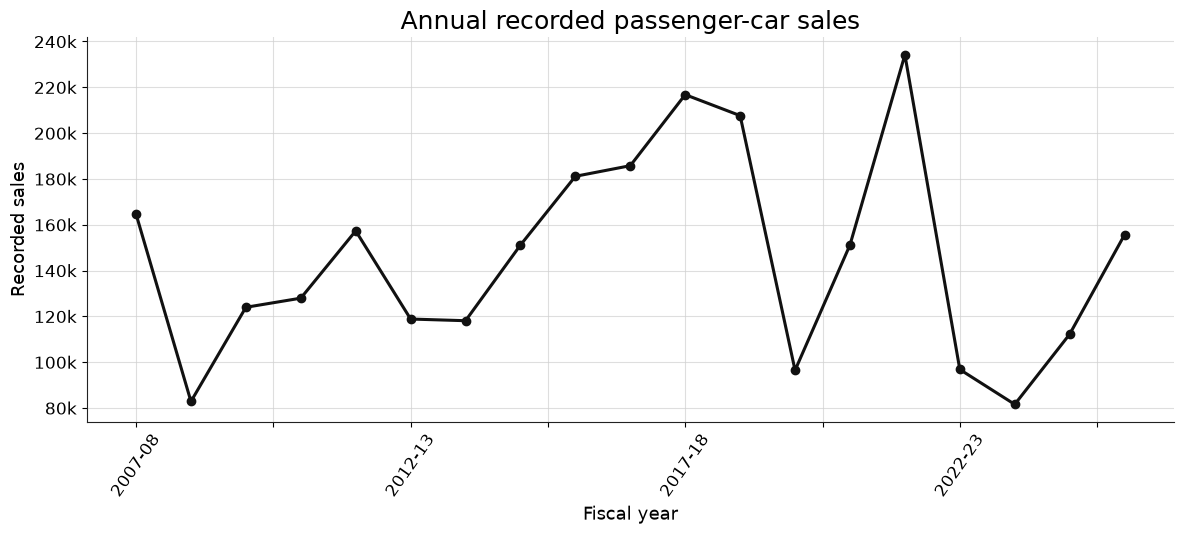

In [15]:
ax = annual_total.plot(
    x="fiscal_year",
    y="total_recorded_sales",
    color="#111111",
    marker="o",
    linewidth=2.2,
    legend=False,
)
ax.set(
    title="Annual recorded passenger-car sales",
    xlabel="Fiscal year",
    ylabel="Recorded sales",
)
ax.tick_params(axis="x", rotation=55)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_formatter(lambda value, _: f"{value / 1000:.0f}k")
plt.tight_layout()
plt.show()


### Interpretation

The figure establishes **when** recorded sales changed and **how large** the recorded changes were.

It cannot establish why sales changed. Claims about prices, policy, supply constraints or consumer preferences require additional evidence.


## 3. Manufacturer shares and CR3

For each fiscal year:

`recorded manufacturer share = manufacturer recorded sales ÷ total recorded passenger-car sales`

The Big Three concentration ratio adds the recorded shares of Suzuki, Toyota and Honda.


In [16]:
annual_brand = (
    sales.groupby(["fiscal_year", "manufacturer"], observed=True, sort=False)["units"]
    .sum()
    .rename("recorded_sales")
    .reset_index()
    .merge(annual_total, on="fiscal_year", how="left")
)
annual_brand["recorded_share"] = (
    annual_brand["recorded_sales"] / annual_brand["total_recorded_sales"]
)

display(annual_brand.head(14))


,fiscal_year,manufacturer,recorded_sales,total_recorded_sales,recorded_share
0,2007-08,Honda,14201,164650,0.086
1,2007-08,Suzuki,102378,164650,0.622
2,2007-08,Toyota,33640,164650,0.204
3,2007-08,Hyundai,2227,164650,0.014
4,2007-08,Daihatsu,12204,164650,0.074
5,2008-09,Honda,11144,82844,0.135
6,2008-09,Suzuki,38684,82844,0.467
7,2008-09,Toyota,26760,82844,0.323
8,2008-09,Hyundai,404,82844,0.005
9,2008-09,Daihatsu,5852,82844,0.071


In [17]:
latest_year = year_order[-1]
latest_brand = (
    annual_brand.loc[annual_brand["fiscal_year"].eq(latest_year)]
    .sort_values("recorded_sales", ascending=False)
    .assign(recorded_share=lambda frame: frame["recorded_share"].map(lambda value: f"{value:.2%}"))
)
display(latest_brand[["manufacturer", "recorded_sales", "recorded_share"]])


,manufacturer,recorded_sales,recorded_share
82,Suzuki,91634,58.88%
83,Toyota,35831,23.02%
81,Honda,24416,15.69%
84,Hyundai,3407,2.19%
86,Honri,343,0.22%
85,BAIC,0,0.00%


In [18]:
big_three = {"Suzuki", "Toyota", "Honda"}

cr3 = (
    annual_brand.loc[annual_brand["manufacturer"].isin(big_three)]
    .groupby("fiscal_year", observed=True, sort=False)["recorded_sales"]
    .sum()
    .rename("big_three_recorded_sales")
    .reset_index()
    .merge(annual_total, on="fiscal_year", how="left")
)
cr3["big_three_recorded_share"] = (
    cr3["big_three_recorded_sales"] / cr3["total_recorded_sales"]
)

display(
    cr3.assign(
        big_three_recorded_share=lambda frame: frame["big_three_recorded_share"].map(
            lambda value: f"{value:.1%}"
        )
    )
)


,fiscal_year,big_three_recorded_sales,total_recorded_sales,big_three_recorded_share
0,2007-08,150219,164650,91.2%
1,2008-09,76588,82844,92.4%
2,2009-10,118412,123957,95.5%
3,2010-11,121937,127944,95.3%
4,2011-12,153468,157325,97.5%
5,2012-13,118759,118830,99.9%
6,2013-14,117950,118102,99.9%
7,2014-15,151084,151134,100.0%
8,2015-16,181138,181145,100.0%
9,2016-17,185780,185781,100.0%


In [19]:
cr3_check = cr3.merge(
    prepared_summary[
        ["fiscal_year", "big_three_recorded_sales", "big_three_recorded_share"]
    ],
    on="fiscal_year",
    suffixes=("_recalculated", "_prepared"),
)
cr3_check["sales_difference"] = (
    cr3_check["big_three_recorded_sales_recalculated"]
    - cr3_check["big_three_recorded_sales_prepared"]
)
cr3_check["share_difference"] = (
    cr3_check["big_three_recorded_share_recalculated"]
    - cr3_check["big_three_recorded_share_prepared"]
)

display(cr3_check)
assert cr3_check["sales_difference"].eq(0).all()
assert cr3_check["share_difference"].abs().lt(1e-12).all()
print("Recalculated CR3 values match the prepared summary.")


,fiscal_year,big_three_recorded_sales_recalculated,total_recorded_sales,big_three_recorded_share_recalculated,big_three_recorded_sales_prepared,big_three_recorded_share_prepared,sales_difference,share_difference
0,2007-08,150219,164650,0.912,150219,0.912,0,0.000
1,2008-09,76588,82844,0.924,76588,0.924,0,0.000
2,2009-10,118412,123957,0.955,118412,0.955,0,0.000
3,2010-11,121937,127944,0.953,121937,0.953,0,0.000
4,2011-12,153468,157325,0.975,153468,0.975,0,-0.000
5,2012-13,118759,118830,0.999,118759,0.999,0,0.000
6,2013-14,117950,118102,0.999,117950,0.999,0,-0.000
7,2014-15,151084,151134,1.000,151084,1.000,0,-0.000
8,2015-16,181138,181145,1.000,181138,1.000,0,-0.000
9,2016-17,185780,185781,1.000,185780,1.000,0,0.000


Recalculated CR3 values match the prepared summary.


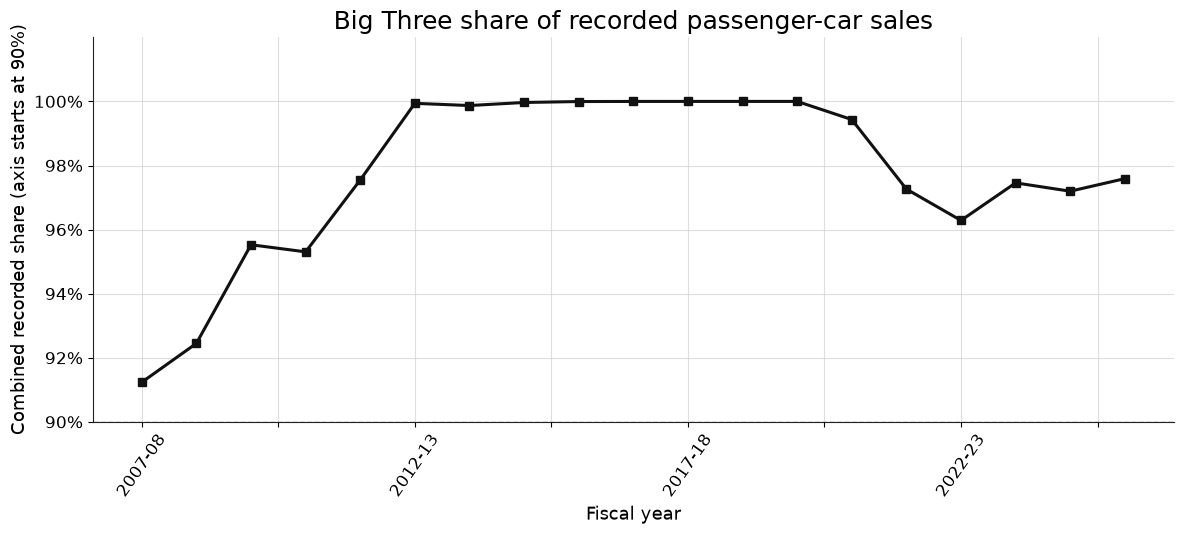

In [20]:
cr3_plot = cr3.assign(
    share_percent=100 * cr3["big_three_recorded_share"]
)

ax = cr3_plot.plot(
    x="fiscal_year",
    y="share_percent",
    color="#111111",
    marker="s",
    linewidth=2.2,
    legend=False,
)
ax.axhline(90, color="#777777", linestyle="--", linewidth=1)
ax.set(
    title="Big Three share of recorded passenger-car sales",
    xlabel="Fiscal year",
    ylabel="Combined recorded share (axis starts at 90%)",
    ylim=(90, 102),
)
ax.set_yticks(
    [90, 92, 94, 96, 98, 100],
    labels=["90%", "92%", "94%", "96%", "98%", "100%"],
)
ax.tick_params(axis="x", rotation=55)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### CR3 interpretation

Within the PAMA passenger-car records, the Big Three retain a very high combined share. This is a conclusion about the **recorded denominator**, not automatically about every new passenger car sold in Pakistan.


## 4. The separately reported electric-car category

The workbook begins showing a separate `DEWAN Honri-Ve` row near the end of the period.

A category's absence in earlier records does not prove that no electric cars existed in Pakistan. It shows only that the prepared records do not contain a separate earlier row with this label.


In [21]:
ev_records = sales.loc[
    sales["model_group"].str.contains("Honri", case=False, na=False)
].copy()

ev_annual = (
    ev_records.groupby("fiscal_year", observed=True, sort=False)["units"]
    .sum()
    .rename("recorded_ev_sales")
    .reset_index()
    .merge(annual_total, on="fiscal_year", how="left")
)
ev_annual["recorded_ev_share"] = (
    ev_annual["recorded_ev_sales"] / ev_annual["total_recorded_sales"]
)

display(
    ev_annual.assign(
        recorded_ev_share=lambda frame: frame["recorded_ev_share"].map(
            lambda value: f"{value:.2%}"
        )
    )
)


,fiscal_year,recorded_ev_sales,total_recorded_sales,recorded_ev_share
0,2024-25,186,112203,0.17%
1,2025-26,343,155631,0.22%


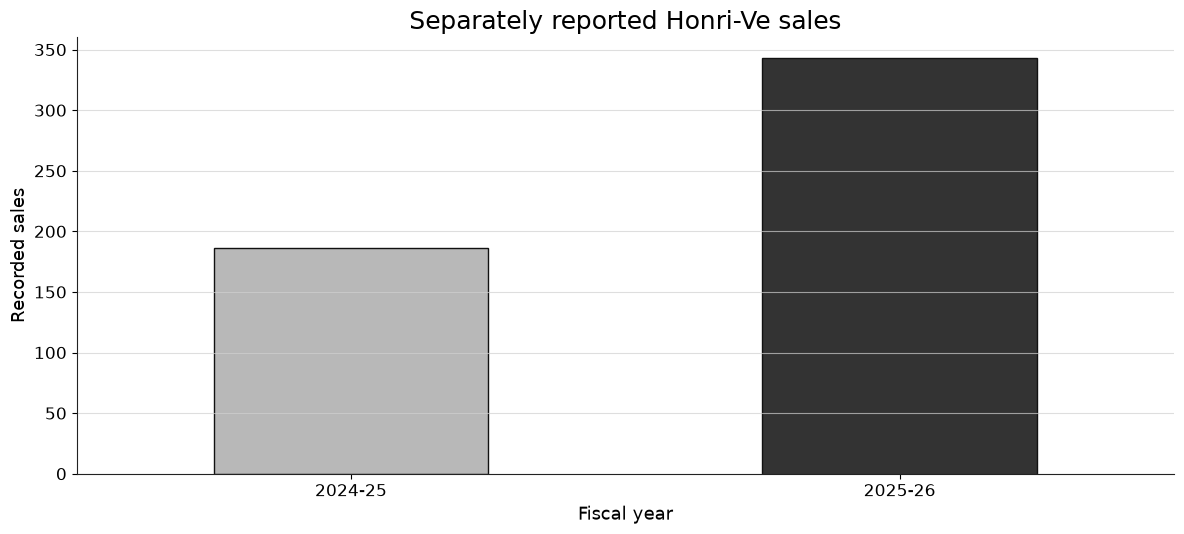

In [22]:
ax = ev_annual.plot(
    x="fiscal_year",
    y="recorded_ev_sales",
    kind="bar",
    color=["#B8B8B8", "#333333"],
    edgecolor="#111111",
    legend=False,
)
ax.set(
    title="Separately reported Honri-Ve sales",
    xlabel="Fiscal year",
    ylabel="Recorded sales",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", visible=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Sensitivity to an incomplete denominator

The 2025-26 records contain:

- 151,881 recorded Big Three sales
- 155,631 total recorded passenger-car sales
- a recorded CR3 of about 97.6 percent

The following scenarios are **hypothetical**, not estimates of omitted sales. They show how an expanded denominator would change the measured share.


In [23]:
latest_cr3 = cr3.loc[cr3["fiscal_year"].eq(latest_year)].iloc[0]
additional_sales = pd.Series([0, 10_000, 25_000, 50_000], name="additional_sales")

sensitivity = additional_sales.to_frame()
sensitivity["big_three_recorded_sales"] = int(
    latest_cr3["big_three_recorded_sales"]
)
sensitivity["expanded_denominator"] = (
    int(latest_cr3["total_recorded_sales"]) + sensitivity["additional_sales"]
)
sensitivity["recalculated_big_three_share"] = (
    sensitivity["big_three_recorded_sales"]
    / sensitivity["expanded_denominator"]
)

display(
    sensitivity.assign(
        recalculated_big_three_share=lambda frame: frame[
            "recalculated_big_three_share"
        ].map(lambda value: f"{value:.1%}")
    )
)


,additional_sales,big_three_recorded_sales,expanded_denominator,recalculated_big_three_share
0,0,151881,155631,97.6%
1,10000,151881,165631,91.7%
2,25000,151881,180631,84.1%
3,50000,151881,205631,73.9%


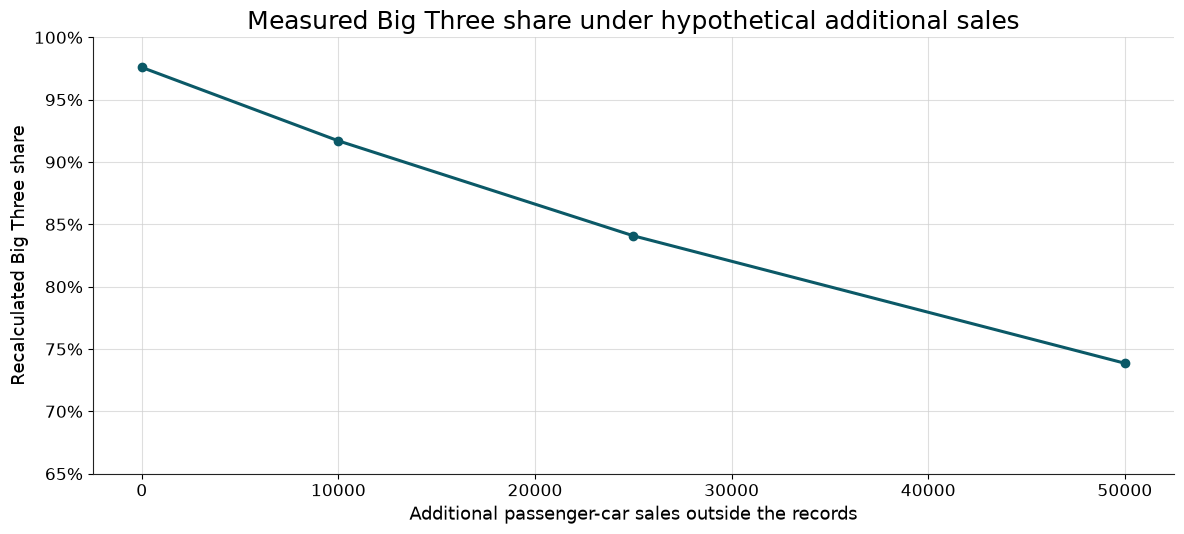

In [24]:
ax = sensitivity.plot(
    x="additional_sales",
    y="recalculated_big_three_share",
    color="#0B5967",
    marker="o",
    linewidth=2.2,
    legend=False,
)
ax.set(
    title="Measured Big Three share under hypothetical additional sales",
    xlabel="Additional passenger-car sales outside the records",
    ylabel="Recalculated Big Three share",
    ylim=(0.65, 1.0),
)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### Sensitivity interpretation

The calculation does not tell us how many sales are missing. It demonstrates that incomplete coverage can materially change a proportion.

A more complete market claim would require additional sources such as provincial registration records, import records, sales from nonmember manufacturers, or a documented PAMA membership history.


## 6. Evidence summary

The final table gathers the principal results and the population they describe.


In [25]:
latest_total = int(
    annual_total.loc[
        annual_total["fiscal_year"].eq(latest_year),
        "total_recorded_sales",
    ].iloc[0]
)
latest_big_three_sales = int(latest_cr3["big_three_recorded_sales"])
latest_big_three_share = float(latest_cr3["big_three_recorded_share"])
latest_ev = ev_annual.loc[ev_annual["fiscal_year"].eq(latest_year)].iloc[0]

evidence_table = pd.DataFrame(
    {
        "evidence": [
            "Total recorded passenger-car sales",
            "Big Three recorded sales",
            "Big Three recorded share",
            "Separately reported Honri-Ve sales",
            "Honri-Ve share of recorded passenger-car sales",
        ],
        latest_year: [
            f"{latest_total:,}",
            f"{latest_big_three_sales:,}",
            f"{latest_big_three_share:.1%}",
            f"{int(latest_ev['recorded_ev_sales']):,}",
            f"{latest_ev['recorded_ev_share']:.2%}",
        ],
    }
)
display(evidence_table)


,evidence,2025-26
0,Total recorded passenger-car sales,"155,631"
1,Big Three recorded sales,"151,881"
2,Big Three recorded share,97.6%
3,Separately reported Honri-Ve sales,343
4,Honri-Ve share of recorded passenger-car sales,0.22%


## Final interpretation

A defensible conclusion contains:

`finding + represented population + limitation`

**Supported conclusion**

Within the PAMA passenger-car records, Suzuki, Toyota and Honda continue to account for nearly all recorded sales.

**Essential limitation**

The workbook alone cannot establish their share of every new passenger car sold in Pakistan because the reporting frame may not cover the complete market.
